[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/04_evaluation.ipynb)

# 04 — Results and How Far to Trust Them

**Question.** Which tilt configuration should be recommended, what does it change on the network, and how
robust is that conclusion?

**Inputs.** The newest run of each method and seed under `outputs/optim/`, the current radio map, and the
processed tables. **Outputs.** `reports/tables/04_evaluation/` and `reports/figures/04_evaluation/`.
No GPU is needed. Every table and figure is built by `src/evaluation/run.py`, the same code `task evaluate` runs.
The Multi-Agent Reinforcement Learning arm is not implemented, so the comparison covers TuRBO and the two baselines.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.export import save_table
from src.evaluation.run import evaluate
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/04_evaluation"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/04_evaluation"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

## 1. Comparability

Runs are compared only if they share the scenario, grid, solver settings, bands and KPI definition.

In [3]:
results = evaluate(cfg, in_colab=IN_COLAB)
checks = results["comparability_checks"]
print(f"{int(checks['Holds'].sum())} of {len(checks)} comparability checks hold")

21 of 21 comparability checks hold


## 2. KPI Scoreboard

Best configuration of each method, averaged over seeds, against the current configuration. A change within a KPI's
tolerance (`configs/kpi.yaml`) is reported as a tie.

,Method,KPI,Direction,Seeds,Current configuration,Mean,Standard deviation,95% CI lower,95% CI upper,Mean change,Tolerance,Verdict
0,Random search,Coverage hole rate,minimise,1,0.1728,0.1755,NaN,NaN,NaN,0.0027,0.002,worse
1,Random search,Co-band overlap rate,minimise,1,0.3292,0.3186,NaN,NaN,NaN,-0.0106,0.001,better
2,Random search,Served UE ratio,maximise,1,0.9102,0.9115,NaN,NaN,NaN,0.0013,0.001,better
3,Random search,Weak coverage rate,minimise,1,0.1444,0.1549,NaN,NaN,NaN,0.0104,0.004,worse
4,Random search,edge_rsrp_dbm,maximise,1,-103.9856,-104.6967,NaN,NaN,NaN,-0.7112,0.500,worse
5,Random search,served_desirability,maximise,1,0.7816,0.7801,NaN,NaN,NaN,-0.0016,0.001,worse
6,Random search,Weighted score,maximise,1,-0.0027,0.0107,NaN,NaN,NaN,0.0135,NaN,
7,Rule-based sweep,Coverage hole rate,minimise,1,0.1728,0.1748,NaN,NaN,NaN,0.0020,0.002,tie (within solver noise)
8,Rule-based sweep,Co-band overlap rate,minimise,1,0.3292,0.3243,NaN,NaN,NaN,-0.0049,0.001,better
9,Rule-based sweep,Served UE ratio,maximise,1,0.9102,0.9110,NaN,NaN,NaN,0.0008,0.001,tie (within solver noise)


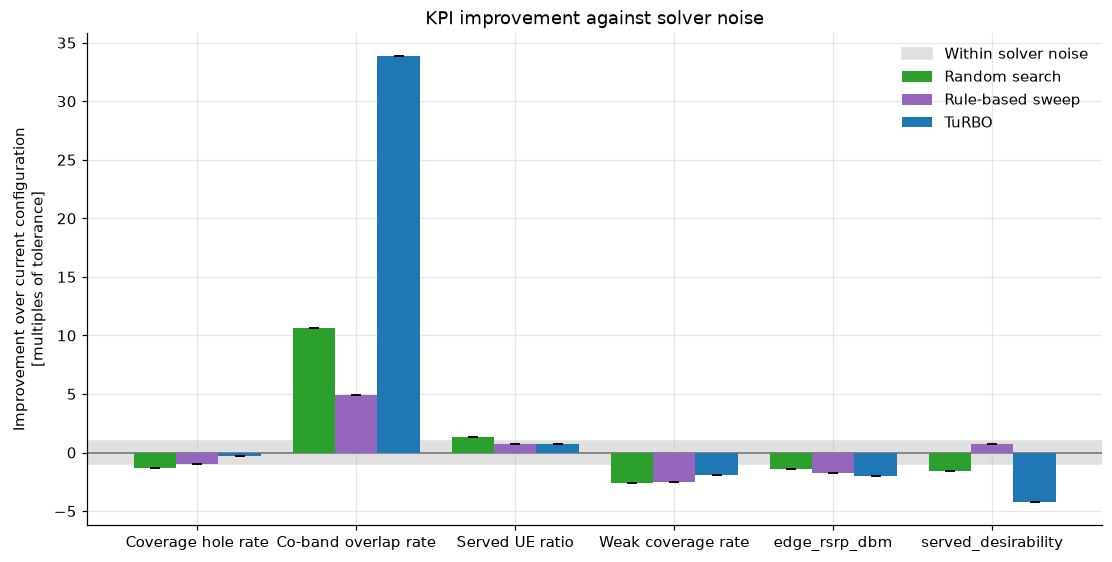

In [4]:
display(results["kpi_scoreboard"])
display(results["kpi_improvement_vs_tolerance"])

**Observations.** _To be written._

## 3. Did the Search Matter?

Each run's best score against the typical candidate it evaluated, and TuRBO against random search paired by seed.

In [5]:
display(results["winner_vs_candidates"])
display(results["paired_gain_turbo_vs_random"])

,Method,Seed,Current configuration,"Initial design, median score","All candidates, median score","All candidates, 90th percentile score",Best score found
0,Random search,42,0.5528,0.3703,0.3857,0.5038,0.5935
1,Rule-based sweep,42,0.5528,NaN,0.5183,0.5655,0.5676
2,TuRBO,42,0.5528,0.3703,0.6332,0.6683,0.6800


,Method,Reference,Seed pairs,Mean score gain,95% CI lower,95% CI upper,Seeds won,Wilcoxon p-value
0,TuRBO,Random search,1,0.0796,NaN,NaN,1,NaN


**Observations.** _To be written._

## 4. Is the Result Robust?

Whether the chosen configurations change under other KPI weights, and whether their improvement survives other
ray-tracer seeds.

In [6]:
display(results["weight_sensitivity"])

,Weighting,Method,Seeds,Mean best score,Rank,Share with unchanged best configuration
0,configured,Random search,1,0.5935,2,1.0
1,configured,Rule-based sweep,1,0.5676,3,1.0
2,configured,TuRBO,1,0.6800,1,1.0
3,equal,Random search,1,0.6327,2,1.0
4,equal,Rule-based sweep,1,0.6028,3,1.0
5,equal,TuRBO,1,0.7160,1,1.0
6,hole_only,Random search,1,0.5328,1,0.0
7,hole_only,Rule-based sweep,1,0.5162,2,0.0
8,hole_only,TuRBO,1,0.5051,3,0.0
9,overlap_only,Random search,1,0.7521,2,0.0


,KPI,Tolerance,"Solver noise, standard deviation",Tolerance / solver noise
0,Coverage hole rate,0.002,0.0011,1.7878
1,Co-band overlap rate,0.001,0.0042,0.2396
2,Served UE ratio,0.001,0.0044,0.2297
3,Weak coverage rate,0.004,0.0033,1.2129
4,edge_rsrp_dbm,0.500,0.5192,0.9630
5,served_desirability,0.001,0.0027,0.3762


,Configuration,Solver seeds,Mean score gain,95% CI lower,95% CI upper,Share of solver seeds improved
0,Random search,5,0.0549,0.0183,0.0915,1.0
1,Rule-based sweep,5,0.0429,0.0025,0.0833,1.0
2,TuRBO,5,0.1499,0.0926,0.2073,1.0


**Observations.** _To be written._

## 5. Where Coverage Changed

Change in best-server signal strength for each method's best configuration, and the coverage holes the recommended
configuration closes or opens.

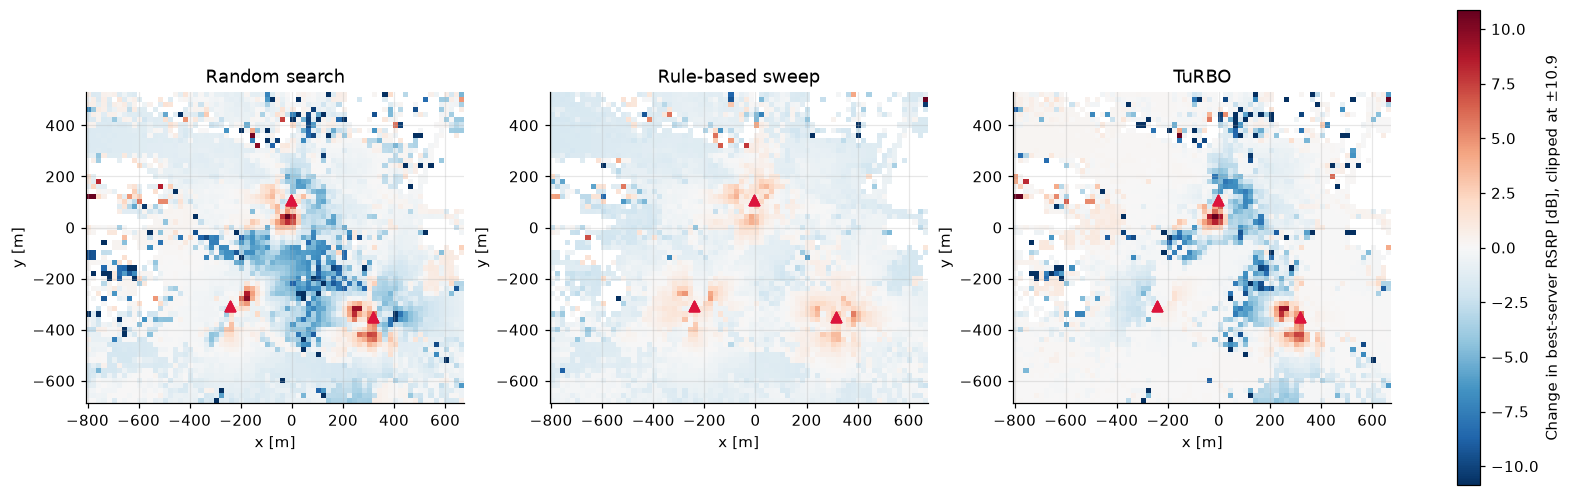

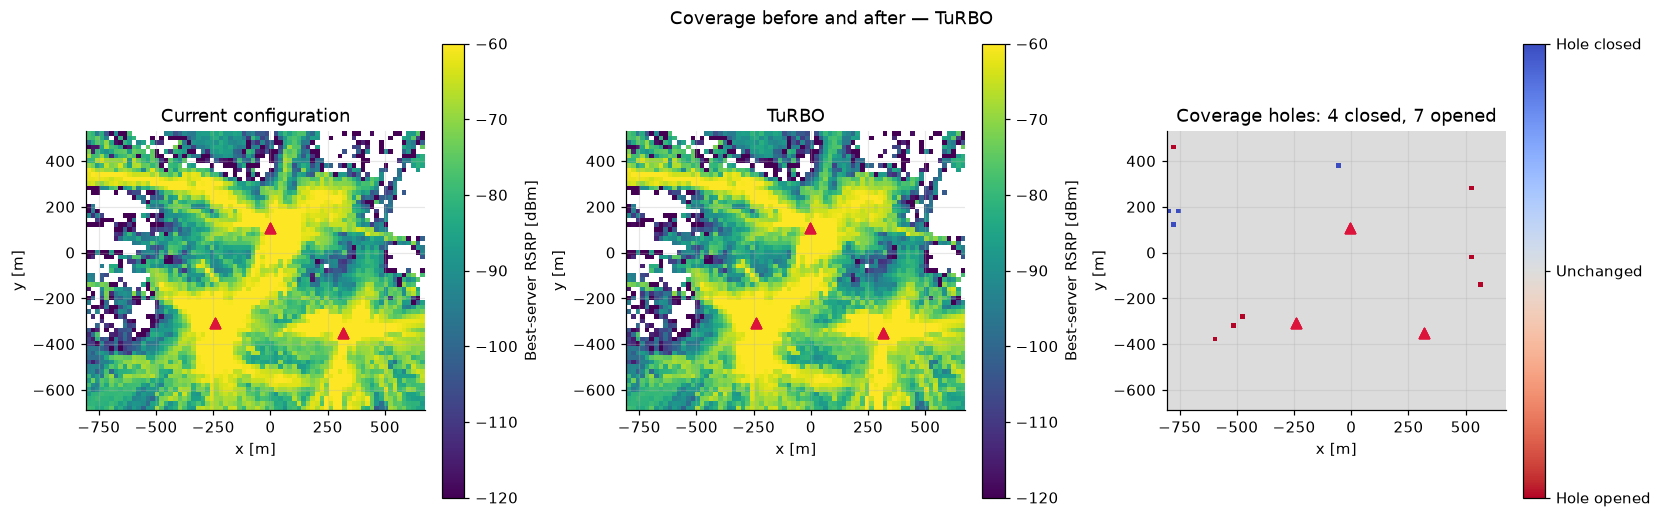

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand,TuRBO: Share of area,TuRBO: Share of demand
0,hole,0.1728,0.0000,0.1755,0.0319,0.1748,0.0323,0.1735,0.0567
1,weak,0.1444,0.7333,0.1549,0.7075,0.1546,0.7020,0.1520,0.6842
2,good,0.6828,0.2667,0.6697,0.2606,0.6706,0.2657,0.6746,0.2591


In [7]:
display(results["rsrp_change_maps"])
display(results["coverage_before_after"])
display(results["coverage_by_area_and_demand"])

**Observations.** _To be written._

## 6. Capacity Impact

Capacity settings are placeholders, so read the direction of change rather than absolute values.

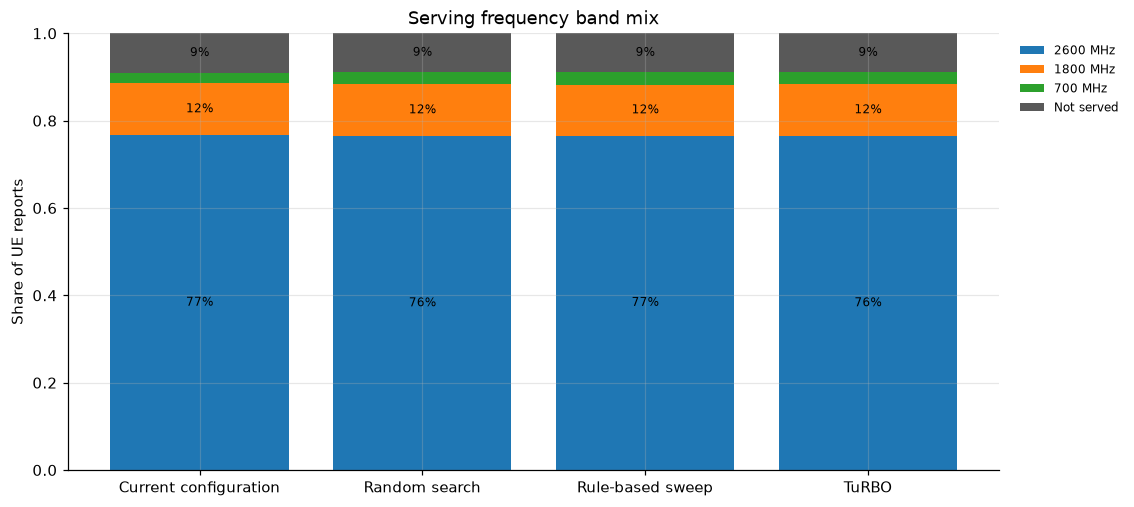

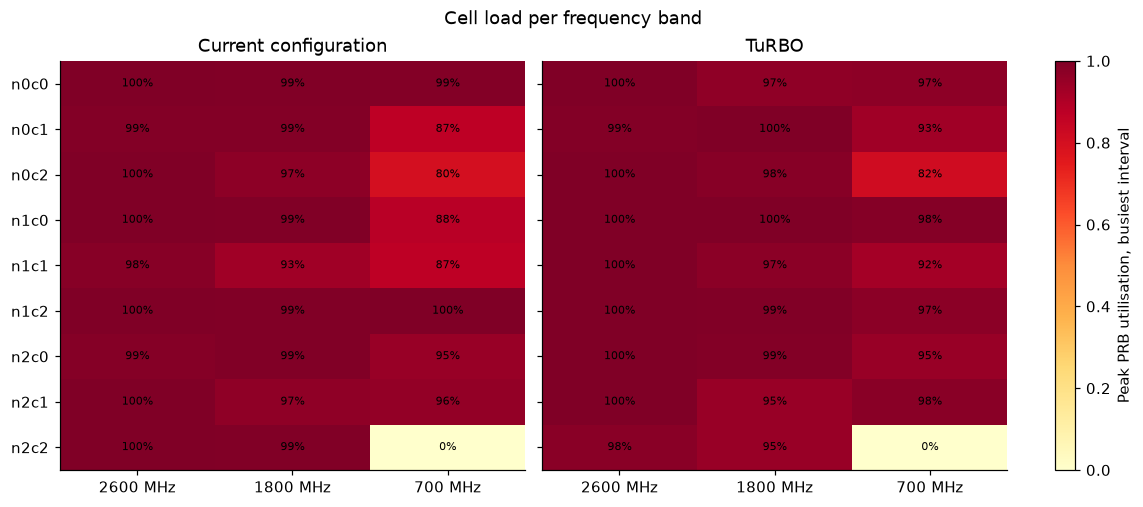

,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,9202.0,0.0898,-0.3070,6.0733,47.5659,0.7669,0.1191,0.0242
1,Random search,9202.0,0.0885,-0.3388,6.1151,47.3396,0.7643,0.1196,0.0276
2,Rule-based sweep,9202.0,0.0890,-0.5382,6.0399,47.7472,0.7660,0.1161,0.0289
3,TuRBO,9202.0,0.0890,-0.4092,6.6868,44.4158,0.7645,0.1194,0.0271


In [8]:
display(results["serving_band_mix"])
display(results["cell_band_utilisation"])
display(results["ue_service_summary"])

**Observations.** _To be written._

## 7. Recommended Tilt Changes

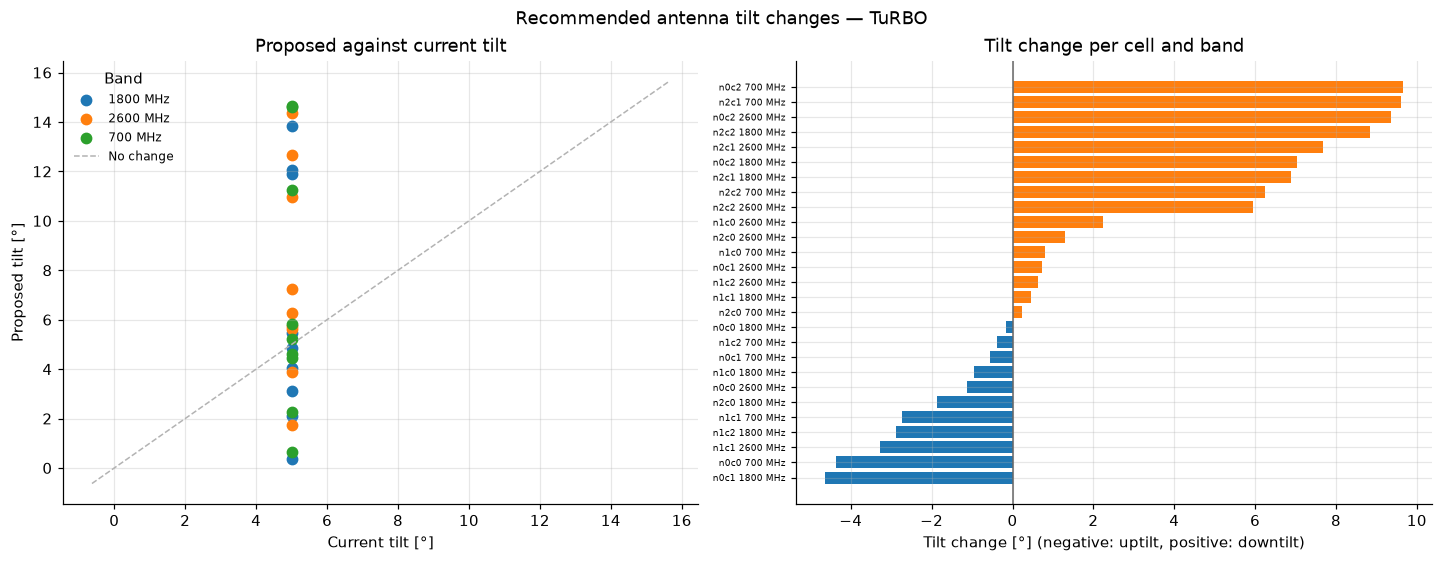

,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,9,9,3.7493,8.8465,1.4143
1,2600 MHz,9,9,3.5864,9.3614,2.6089
2,700 MHz,9,9,3.8423,9.6563,2.0595


,Node,Cell,Azimuth [°],Band,Current tilt [°],Proposed tilt [°],Tilt change [°],"Served reports, before","Peak PRB utilisation, before",Median SINR before [dB],"Served reports, after","Peak PRB utilisation, after",Median SINR after [dB],"Served reports, change","Peak PRB utilisation, change",Median SINR change [dB]
0,n0,n0c2,270.0,2600 MHz,5.0,14.3614,9.3614,684,0.9987,2.6003,343,0.9976,2.2870,-341,-1.0968e-03,-0.3133
1,n0,n0c0,30.0,2600 MHz,5.0,3.8751,-1.1249,937,0.9997,5.4465,1236,0.9996,7.6740,299,-7.3071e-05,2.2275
2,n2,n2c1,150.0,2600 MHz,5.0,12.6696,7.6696,652,0.9968,5.5171,489,0.9987,3.9698,-163,1.8365e-03,-1.5473
3,n1,n1c0,30.0,2600 MHz,5.0,7.2418,2.2418,1014,0.9987,2.4824,1135,0.9998,3.2940,121,1.1383e-03,0.8116
4,n0,n0c1,150.0,2600 MHz,5.0,5.7348,0.7348,833,0.9920,17.7055,896,0.9918,16.7849,63,-2.5603e-04,-0.9206
5,n1,n1c1,150.0,2600 MHz,5.0,1.7260,-3.2740,582,0.9824,8.1191,536,0.9972,6.6366,-46,1.4758e-02,-1.4825
6,n1,n1c2,270.0,2600 MHz,5.0,5.6396,0.6396,1314,0.9987,8.3019,1358,0.9993,8.7538,44,5.8904e-04,0.4519
7,n1,n1c0,30.0,1800 MHz,5.0,4.0363,-0.9637,216,0.9940,3.4143,245,0.9991,4.2187,29,5.1312e-03,0.8045
8,n0,n0c0,30.0,1800 MHz,5.0,4.8422,-0.1578,148,0.9939,9.3430,175,0.9682,9.7619,27,-2.5725e-02,0.4188
9,n0,n0c2,270.0,1800 MHz,5.0,12.0417,7.0417,54,0.9715,4.1853,28,0.9844,2.5924,-26,1.2829e-02,-1.5929


In [9]:
display(results["tilt_movement"])
display(results["tilt_movement_summary"])
display(results["cell_impact"])

**Observations.** _To be written._

## 8. Search Cost and Progress

,Method,Seed,Run,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,edge_rsrp_dbm,served_desirability,Weighted score,KPIs improved,KPIs worsened
0,Random search,42,2026-09-16_02-58-37,145,18,9.1385,10.7920,0.1755,0.3186,0.9115,0.1549,-104.6967,0.7801,0.0107,2,4
1,Rule-based sweep,42,2026-09-16_03-09-29,29,22,1.1794,1.4655,0.1748,0.3243,0.9110,0.1546,-104.8523,0.7823,-0.0048,1,2
2,TuRBO,42,2026-09-16_02-37-12,145,144,10.5233,20.8071,0.1735,0.2953,0.9110,0.1520,-104.9728,0.7773,0.0903,1,3


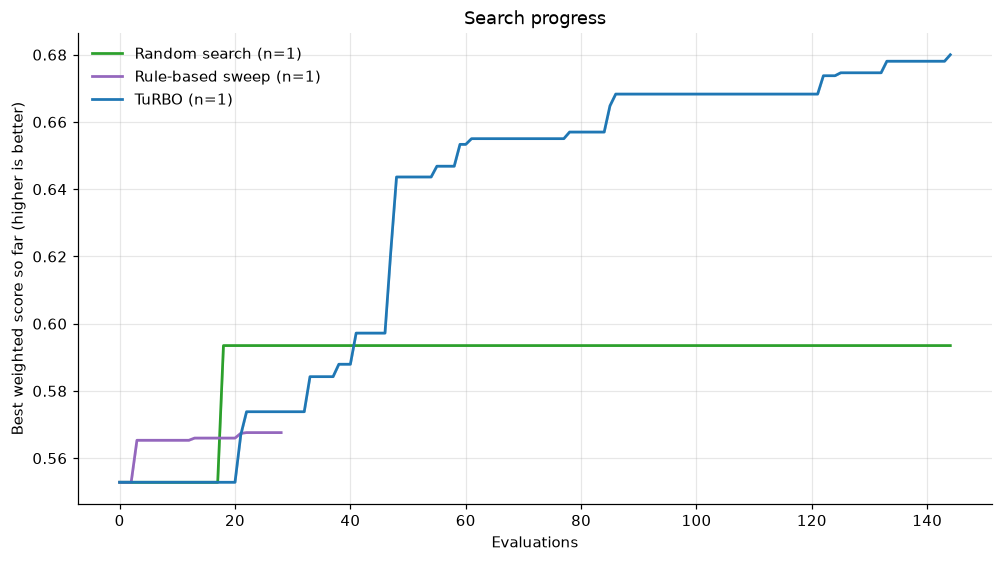

In [10]:
display(results["method_cost"])
display(results["search_progress"])

**Observations.** _To be written._

## 9. Threats to Validity

| # | Threat | Evidence | Status |
|---|---|---|---|
| 1 | One scenario: every configuration is tuned and scored on the same city and population, so no result measures generalisation | — | Open: held-out scenarios are not implemented |
| 2 | Winner's curse: the best of many evaluations under one solver seed is biased upward | Section 4, re-traced gain | Mitigated |
| 3 | Weak reference: the current configuration uses identical default tilts, and the 2600 MHz tilt starts at its upper bound | Section 3, winner against candidates; notebook 02, decision variables | Mitigated |
| 4 | Too few runs to compare methods | Sections 2 and 3, intervals and paired test over seeds | Mitigated; power remains limited by the number of seeds |
| 5 | The weighted score depends on judgement weights that are not normalised | Section 4, weight sensitivity | Mitigated |
| 6 | Hole and weak rates count area, including area without users | Section 5, coverage by area and by demand | Reported |
| 7 | The served ratio relies on placeholder capacity settings; UEs no cell reaches are excluded before it is computed | Notebook 01, data quality | Open |
| 8 | Physical simplifications: full-load SINR, Shannon rate without MCS, no calibration against field measurements, reported RSRP below the 3GPP reporting range | Notebook 01, data quality | Open |
| 9 | The project title names Multi-Agent Reinforcement Learning, which is not implemented | — | Open |
| 10 | The rule-based sweep is not budget-matched; tilt movement and operational cost are not constrained | Sections 7 and 8 | Reported |